# Optimzation of filter and scintillator thickness's

## Imports

In [1]:
import os
import sys
from pathlib import Path
import ipynbname

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tifffile import imread

from gvxrPython3 import gvxr
from gvxrPython3.utils import has_k3d, visualise

from gvxrPython3.JSON2gVXRDataReader import *

from cil.processors import TransmissionAbsorptionConverter
from cil.utilities.display import show_geometry, show2D
from cil.utilities.jupyter import islicer, link_islicer

#3D viewing and interacting
from ipywidgets import interact
import pyvista as pv


xsim_root = ipynbname.path().parent.parent.parent
print(xsim_root)

class_root = xsim_root / "Classes"
print(class_root)

sys.path.append(str(xsim_root))

#own class imports
from Classes.Nanotom_class.NanotomXCT import NanotomXCT
from Classes.Visualiser_class.xct_visualiser import XCT_Visualiser
from Classes.Comparisor_class.xct_comparisor import *

c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim
c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Classes


## Paths

In [2]:
output_path = xsim_root / "Results/Al_crucible/"
data_path = xsim_root / "Data/"
real_preojections_path = data_path / "Al_crucible/Projections/"
root = xsim_root / "Nanotom/Optimization/"
meshes_root = xsim_root / "Data/Al_crucible/Mesh/"

print(output_path)
print(root)
print(meshes_root)
print(data_path)
print(real_preojections_path)

c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Results\Al_crucible
c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Nanotom\Optimization
c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Data\Al_crucible\Mesh
c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Data
c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Data\Al_crucible\Projections


## Acquisition settings

In [3]:
SDD=499.99690000
SSD=24.99990000

scaling = 1
current = 0.3 #mA
exp_time = 0.375013 #s
volt = 60 #kV

detector_x = 2048
detector_y = 1000

num_of_proj = 2000

In [ ]:
nanotom = NanotomXCT(scaling, output_path=output_path)

nanotom.set_distances(SSD, SDD)
nanotom.setup_detector(detector_x, detector_y, scintillator=None)
nanotom.setup_source(volt, current, exp_time, poly=True, filter=None, noise=False)

s = sp.Spek(kvp= 60 , th= 12 , mas= 0.11250389999999999 , z= 49.999691009521484
990862492.4805031  photons / cm^2
99086.25072455048  photons / pixel


## Loading mesh and applying material composition

In [6]:
mesh_Al = meshes_root / "Al crucible mesh.stl"
            
nanotom.addMesh("Al_crucible", mesh_Al, gvxr.getDensityFromElement("Al"),element="Al")

## Cropping function
##### This needs to be done because the mesh extracted from the experimental scan contained artifacts and is therefore missing a part of its volume at the bottom 

In [8]:
def crop_pixels(img, top=0, bottom=0, left=0, right=0):
    """
    Crop an image by removing a specific number of pixels
    from each side.

    Args:
        img: NumPy array (H, W) or (H, W, C)
        top, bottom, left, right: number of pixels to remove

    Returns:
        Cropped NumPy array
    """
    H, W = img.shape[:2]

    # Clamp values to avoid empty or inverted images
    top = min(max(top, 0), H)
    bottom = min(max(bottom, 0), H - top)
    left = min(max(left, 0), W)
    right = min(max(right, 0), W - left)

    return img[top:H-bottom, left:W-right, ...]

## Optimization function

In [9]:
def optimize_parameters(filter_values, scintillator_values, scintillator_materials, th_degs, reference_image, weight_ssim=1/3, weight_rmse=1/3, weight_hi=1/3):

    F = len(filter_values)
    S = len(scintillator_values)

    # Matrices to store results
    #cc_map = np.zeros((F, S))
    ssim_map = np.zeros((F, S))
    score_map = np.zeros((F, S))
    rmse_map = np.zeros((F, S))
    hi_map = np.zeros((F, S))

    best_rmse = np.inf
    best_rmse_params = None
    best_ssim = -np.inf
    best_ssim_params = None
    best_hi = -np.inf
    best_hi_params = None

    best_score = -np.inf
    best_params = None
    best_metrics = None

    for i, f_thick in enumerate(filter_values):
        for j, s_thick in enumerate(scintillator_values):
            for mat in scintillator_materials:
                for deg in th_degs:
                    # Simulate
                    f_thick = np.round(f_thick, 3)
                    s_thick = np.round(s_thick, 3)
                    gvxr.setScintillator(mat, s_thick, "um")
                    filter = [["Al", f_thick]]
                    nanotom.setup_source(volt, current, exp_time, th_deg=deg, poly=True, filter=filter, noise=True)
                    sim_img = nanotom.compute2D()
                    sim_img = crop_pixels(sim_img, 200, 200, 300, 200)

                    # Metrics
                    #cc = zncc(sim_img, reference_image)
                    ssim_val = ssim(sim_img, reference_image)
                    if ssim_val > best_ssim:
                        best_ssim = ssim_val
                        best_ssim_params = (f_thick, s_thick, mat, deg)

                    rmse_val = rmse(sim_img, reference_image)
                    if rmse_val < best_rmse:
                        best_rmse = rmse_val
                        best_rmse_params = (f_thick, s_thick, mat, deg)

                    hi_val = hi(sim_img, reference_image)
                    if hi_val > best_hi:
                        best_hi = hi_val
                        best_hi_params = (f_thick, s_thick, mat, deg)

                    score = weight_ssim * ssim_val + weight_rmse * (1-rmse_val) + weight_hi * hi_val

                    # Store in matrices
                    #cc_map[i, j] = cc
                    ssim_map[i, j] = ssim_val
                    rmse_map[i, j] = rmse_val
                    hi_map[i, j] = hi_val
                    score_map[i, j] = score

                    # Print current filter and scintillator thicknesses
                    print(f"Filter={f_thick}, Scint={s_thick}S, SSIM={ssim_val:.4f}, RMSE={rmse_val:.4f}, HI={hi_val:.4f}, SCORE={score:.4f}")

                    # Stores best results
                    if score > best_score:
                        best_score = score
                        best_params = (f_thick, s_thick, mat, deg)
                        best_metrics = { "ssim": ssim_val, "rmse": rmse_val, "HI": hi_val, "score": score}

    results = (f"Best RMSE: {best_rmse} with: {best_rmse_params} \n"
          + f"Best SSIM: {best_ssim} with : {best_ssim_params} \n"
          + f"Best HI: {best_hi} with: {best_hi_params} \n"
          + f"Best joined score: {best_metrics} with: {best_params}")

    return results, ssim_map, rmse_map, hi_map, score_map

## Heatmat of optimisation results

In [10]:
def plot_heatmap(filter_values, scintillator_values, score_map, rmse=False, title="Score Map"):

    plt.figure(figsize=(8, 6))

    # Draw heatmap
    im = plt.imshow(score_map,
                    origin='lower',
                    aspect='auto',
                    cmap='viridis',
                    extent=[scintillator_values[0], scintillator_values[-1],
                            filter_values[0], filter_values[-1]])

    plt.colorbar(im, label="Score")

    plt.xlabel("Scintillator Thickness (µm)")
    plt.ylabel("Filter Thickness (mm)")
    plt.title(title)

    # --- Find the max score ---
    if rmse:
        max_idx = np.unravel_index(np.argmin(score_map), score_map.shape)
    else:
        max_idx = np.unravel_index(np.argmax(score_map), score_map.shape)
    i, j = max_idx

    best_f = filter_values[i]
    best_s = scintillator_values[j]
    best_score = score_map[i, j]

    # --- Mark the best point ---
    plt.scatter(best_s, best_f,
                color="red",
                s=120,
                marker="X",
                edgecolors="black",
                linewidth=1.2)

    # --- Add annotation ---
    plt.text(best_s, best_f,
             f"{best_score:.3f}",
             color="white",
             fontsize=10,
             ha="left", va="bottom",
             bbox=dict(facecolor="black", alpha=0.6, pad=2))

    plt.tight_layout()
    plt.show()

## Selecting the ranges for the optimization

In [11]:
filter_vals = np.arange(0.2, 0.4 + 0.001, 0.01)
scintillator_vals = np.arange(400, 600+0.001, 5)
scint_mats = ('Y2O3', 'Gd2O2S DRZ-Plus', 'Gd2O3', 'CdWO4')
th_in_degs = np.arange(10, 16+0.001, 1)

#### Importing experimental Al crucible projection as reference image

In [11]:
n = "00001"
real_img = get_org_projection(real_preojections_path/ f"Al crucible_3{n}.tif", scaling=scaling, flip=True)
white_value = real_img[:10,:].mean()
real_img /= white_value
real_img = crop_pixels(real_img, 200, 200, 300, 200)

### Running the optimization

In [ ]:
results, ssim_map, rmse_map, hi_map, score_map = optimize_parameters(filter_vals, scintillator_vals, scint_mats, th_in_degs,  real_img)

In [ ]:
print("Results: " + str(results))
plot_heatmap(filter_vals, scintillator_vals, score_map, title="Combined Score Map")
plot_heatmap(filter_vals, scintillator_vals, rmse_map, rmse=True, title="RMSE Map")
plot_heatmap(filter_vals, scintillator_vals, hi_map, title="Histrogram I Map")
plot_heatmap(filter_vals, scintillator_vals, ssim_map, title="SSIM Map")

## Applying found settings and generating comparison and metrics

In [ ]:
#0.25, 530.0, 'Gd2O2S'
filt_thick, scint_thick, scint_mat, degs = (0.26, 525.0, 'CdWO4', 12.0) 

gvxr.setScintillator(scint_mat, scint_thick, "um")
filter = [["Al", filt_thick]]
nanotom.setup_source(volt, current, exp_time, th_deg=degs, poly=True, filter=filter, noise=True)
sim_img = nanotom.compute2D()
sim_img = crop_pixels(sim_img, 200, 200, 300, 200)

In [12]:
images = {"Real Projection": real_img,
          "Simulated Projection": sim_img}

In [ ]:
print(output_path)
os.makedirs(output_path / "Metrics/", exist_ok=False)
metrics_path = output_path / "Metrics/"

In [ ]:
two_line_plot(images, 350, save=False, title="Al Crucible - Optimized-Proj1", path=metrics_path)
get_metrics(sim_img, real_img, "")


RMSE: 0.14986876
ZNCC: 0.95818883
SSIM: 0.9224365950365883
HI: 0.3280254091300603


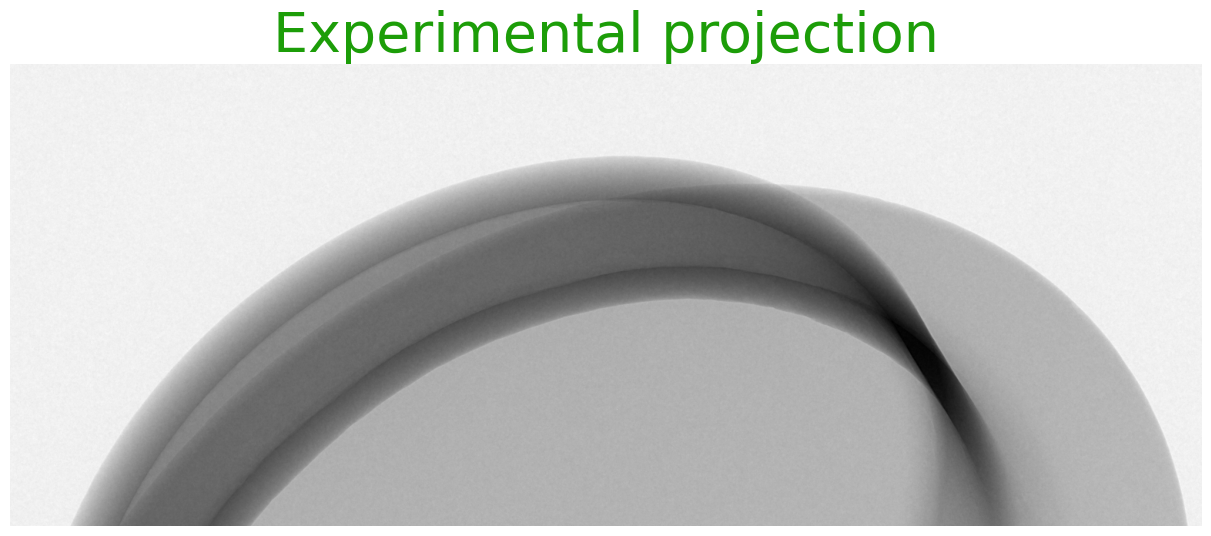

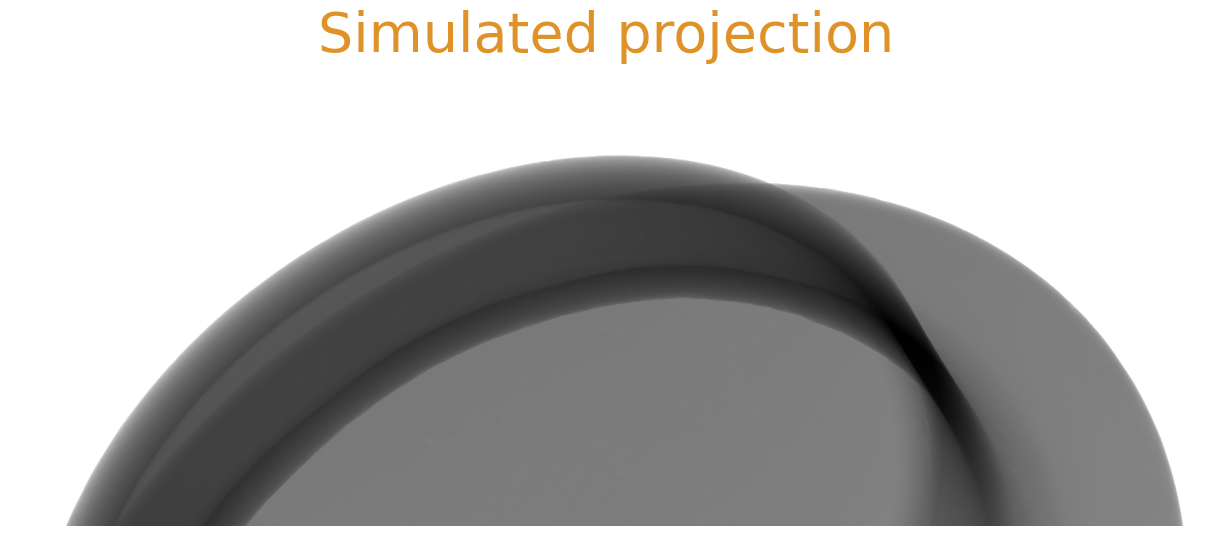

In [15]:
plt.figure(figsize=(16,6))
plt.axis("off")
plt.title("Experimental projection", color="#1c9d08ff", fontsize=40)
plt.imshow(real_img, cmap="gray")
plt.figure(figsize=(16,6))
plt.axis("off")
plt.title("Simulated projection", color="#df9227ff", fontsize=40)
plt.imshow(sim_img, cmap="gray")

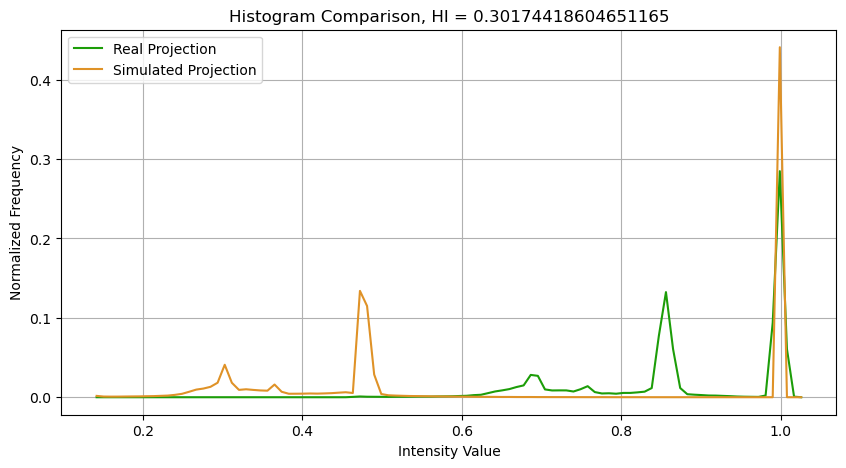

In [34]:
histogram_plot(img_org=real_img, img_sim=sim_img)

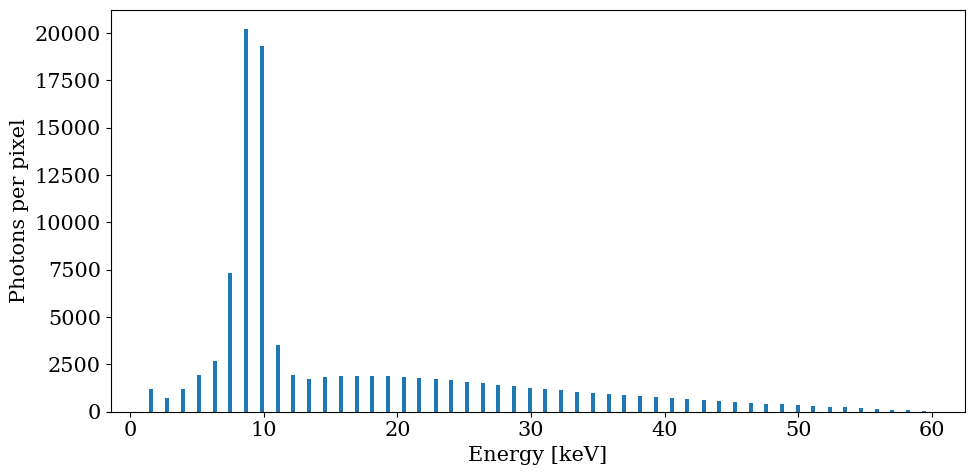

In [16]:
font = {'family' : 'serif',
            'size'   :  15
        }
matplotlib.rc('font', **font)

energy_bins = gvxr.getEnergyBins("keV")
photon_count = np.array(gvxr.getPhotonCountEnergyBins(), dtype=float)

plt.figure(figsize= (10,5))
plt.bar(energy_bins, photon_count, width=0.3)
plt.xlabel('Energy [keV]')
plt.ylabel('Photons per pixel')
plt.tight_layout()
plt.show()


In [20]:
gvxr.destroy()